In [66]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('electronic_sales.csv')
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [67]:
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Add-on Total'] = df['Add-on Total'].fillna(0)

payments = (df.groupby(['Customer ID', 'Payment Method'])
            .size()
            .reset_index(name='count')
            .sort_values(['Customer ID', 'count', 'Payment Method'], ascending=[True, False, True]))

preferred_payment = (payments.drop_duplicates('Customer ID')
                     .rename(columns={'Payment Method': 'preferred_payment'})
                     [['Customer ID', 'preferred_payment']])

customers = (df.groupby('Customer ID')
             .agg(total_spent=('Total Price', 'sum'), addons_spent=('Add-on Total', 'sum'), orders_count=('Customer ID', 'count'))
             .reset_index()
             .merge(preferred_payment, on='Customer ID')
             [['Customer ID', 'preferred_payment', 'total_spent', 'addons_spent', 'orders_count']]
             .sort_values('total_spent', ascending=False))

customers.head(10)

,Customer ID,preferred_payment,total_spent,addons_spent,orders_count
9728,16357,Bank Transfer,34563.70,495.19,7
10049,16863,PayPal,33035.92,486.17,5
8060,13813,Credit Card,31830.16,268.64,5
6475,11476,PayPal,31077.61,301.59,5
7028,12276,Bank Transfer,30961.18,329.07,6
7935,13635,Credit Card,30260.36,480.73,5
7352,12749,Credit Card,29394.56,619.43,5
9087,15399,PayPal,29084.88,305.39,3
7054,12319,Bank Transfer,27352.32,226.38,3
12133,19996,Bank Transfer,27296.78,432.12,6


In [68]:
def clean(df):
    df = df.copy()
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
    df = df.dropna(subset=['Purchase Date'])
    df = df[df['Unit Price'] > 0]
    df = df[df['Total Price'] > 0]
    df['Add-on Total'] = df['Add-on Total'].fillna(0)
    return df


def build_metrics(df):
    revenue_by_shipping = df.groupby('Shipping Type')['Total Price'].sum().reset_index(name='revenue')
    revenue_by_product = df.groupby('Product Type')['Total Price'].sum().reset_index(name='revenue')
    df['month'] = df['Purchase Date'].dt.to_period('M')
    df['quarter'] = df['Purchase Date'].dt.to_period('Q')
    addons_by_month = df.groupby('month')['Add-on Total'].sum().reset_index(name='addons_revenue')
    addons_by_quarter = df.groupby('quarter')['Add-on Total'].sum().reset_index(name='addons_revenue')
    df['cohort'] = df.groupby('Customer ID')['month'].transform('min')
    df['month_number'] = df['month'].astype(int) - df['cohort'].astype(int)
    cohort_data = df[df['month_number'] <= 3]
    cohort_revenue = cohort_data.pivot_table(index='cohort', columns='month_number', values='Total Price', aggfunc='sum').reindex(columns=[0, 1, 2, 3])
    cohort_customers = cohort_data.pivot_table(index='cohort', columns='month_number', values='Customer ID', aggfunc='nunique').reindex(columns=[0, 1, 2, 3])

    return {'revenue_by_shipping': revenue_by_shipping, 'revenue_by_product': revenue_by_product, 'addons_by_month': addons_by_month, 'addons_by_quarter': addons_by_quarter, 'cohort_revenue': cohort_revenue, 'cohort_customers': cohort_customers}


df_clean = clean(df)
metrics = build_metrics(df_clean)

In [69]:
metrics['revenue_by_shipping']

metrics['revenue_by_product']

metrics['addons_by_month'].head()

metrics['cohort_revenue']

month_number,0,1,2,3
cohort,,,,
2023-09,481961.79,50514.74,47257.20,51120.20
2023-10,2267951.61,155302.95,239168.06,199974.25
2023-11,1865873.99,128478.44,186910.97,98007.62
2023-12,1561933.63,154981.79,105574.15,114670.83
2024-01,6034006.07,563400.17,723336.79,672185.51
2024-02,4734162.29,491320.81,527889.65,607050.30
2024-03,4631455.70,550615.28,488574.18,489712.08
2024-04,4122813.88,396920.86,511530.09,490340.42
2024-05,3870243.83,377504.74,515389.20,345730.60


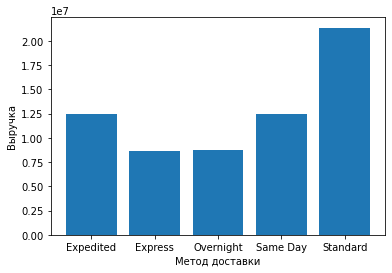

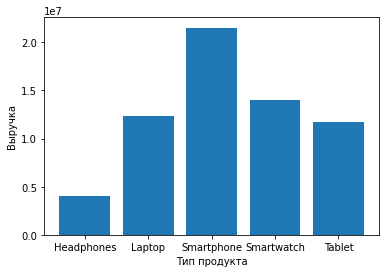

In [70]:
plt.bar(metrics['revenue_by_shipping']['Shipping Type'], metrics['revenue_by_shipping']['revenue'])
plt.xlabel('Метод доставки')
plt.ylabel('Выручка')
plt.show()

plt.bar(metrics['revenue_by_product']['Product Type'], metrics['revenue_by_product']['revenue'])
plt.xlabel('Тип продукта')
plt.ylabel('Выручка')
plt.show()

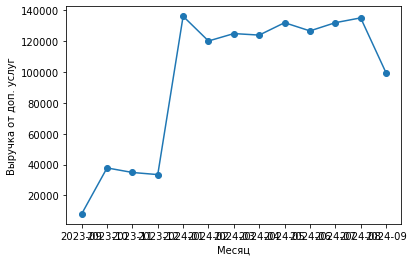

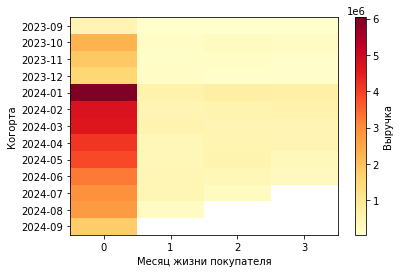

In [71]:
plt.plot(metrics['addons_by_month']['month'].astype(str), metrics['addons_by_month']['addons_revenue'], marker='o')
plt.xlabel('Месяц')
plt.ylabel('Выручка от доп. услуг')
plt.show()

plt.imshow(metrics['cohort_revenue'], cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Выручка')
plt.xlabel('Месяц жизни покупателя')
plt.ylabel('Когорта')
plt.xticks([0, 1, 2, 3])
plt.yticks(range(len(metrics['cohort_revenue'])), metrics['cohort_revenue'].index.astype(str))
plt.show()